# Conociendo el dataset

Lo que trata: identifica si una red hay una amenaza en base a su uso

In [9]:
# Imports
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

I0000 00:00:1773776925.542896   26181 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1773776925.544510   26181 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [10]:
# Cargar dataset
df = pd.read_csv("data/networkanomalydataset.csv")
# Mostrar primeras filas
df.head(5)

,Inbound Rate(bit/s),Outbound Rate(bit/s),Inbound Bandwidth Utilization(%),Outbound Bandwidth Utilization(%),Label
0,0.931000,1.224246,0.931001,1.224244,0
1,0.965773,1.302733,0.965944,1.303585,0
2,1.018103,1.341763,1.017932,1.342183,0
3,1.088629,1.374144,1.088671,1.374348,0
4,1.128772,1.381435,1.128727,1.380781,0


In [11]:
df.isnull().sum()

Inbound Rate(bit/s)                  0
Outbound Rate(bit/s)                 0
Inbound Bandwidth Utilization(%)     0
Outbound Bandwidth Utilization(%)    0
Label                                0
dtype: int64

### No hay datos faltantes

Aqui se esta aplicando EDA
mas info en: https://medium.com/@amaanuddinparvez/network-anomaly-detection-using-machine-learning-a-complete-guide-39165c04e373

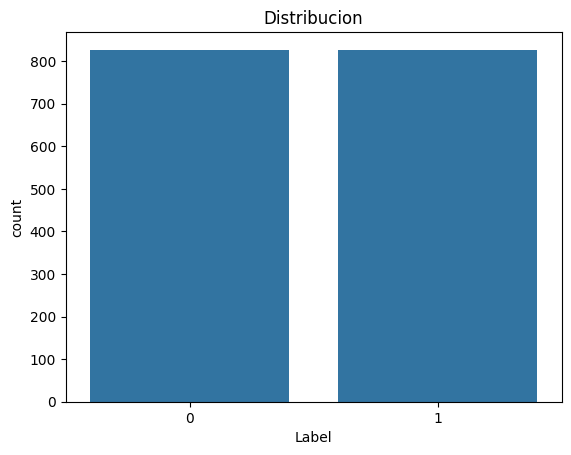

In [12]:
sns.countplot(x="Label", data=df)
plt.title('Distribucion')
plt.show()

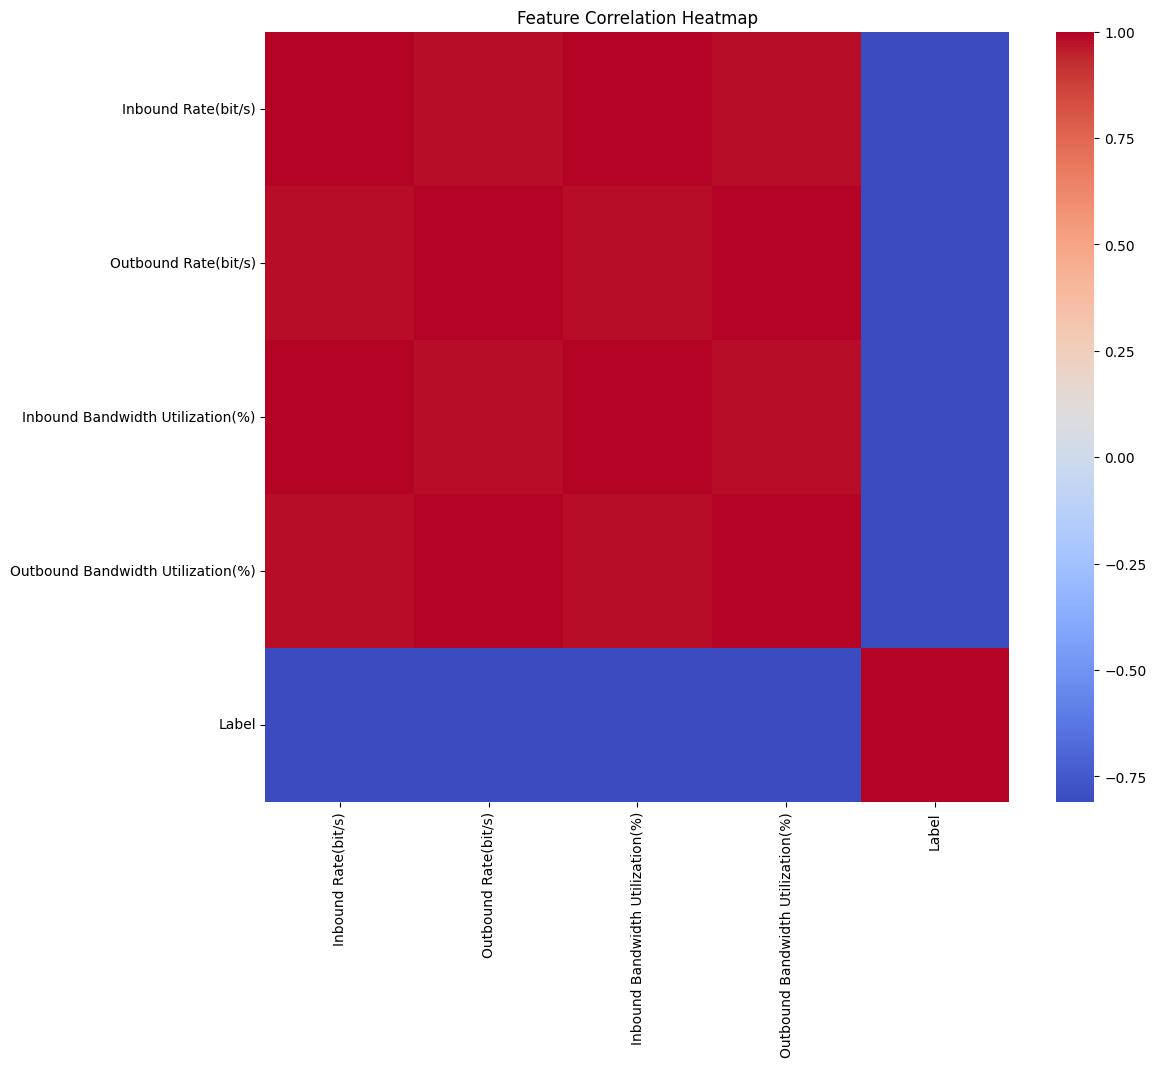

In [13]:
# Correlation heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(), cmap='coolwarm', annot=False)
plt.title('Feature Correlation Heatmap')
plt.show()


In [14]:
np.random.seed(42)

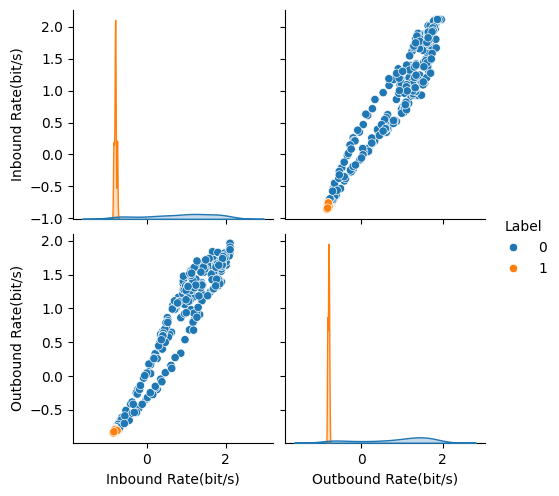

In [15]:
# Pairplot for selected features
sampled_df = df.sample(500)
sns.pairplot(sampled_df[['Inbound Rate(bit/s)',
                         'Outbound Rate(bit/s)',
                         'Label']], hue='Label')
plt.show()



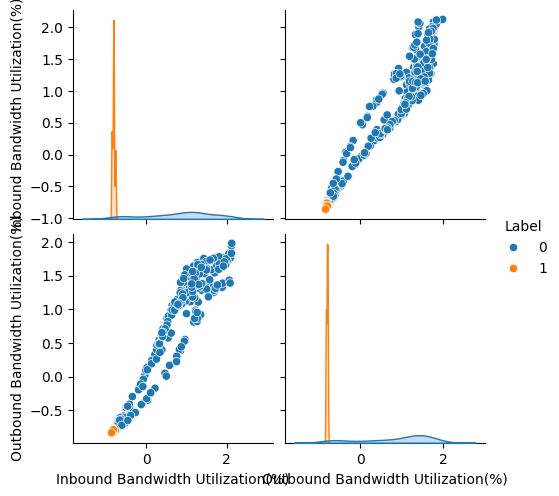

In [16]:
# Pairplot for selected features
sampled_df = df.sample(500)
sns.pairplot(sampled_df[['Inbound Bandwidth Utilization(%)',
                         'Outbound Bandwidth Utilization(%)',
                         'Label']], hue='Label')
plt.show()


## Deteccion de outliner

## TODO:
    * Investigar las diferentes tecncias de identificacion de datos anomalos
    * Desarrollarlo
    * Argumentarlo
    * decidir si eliminarlo

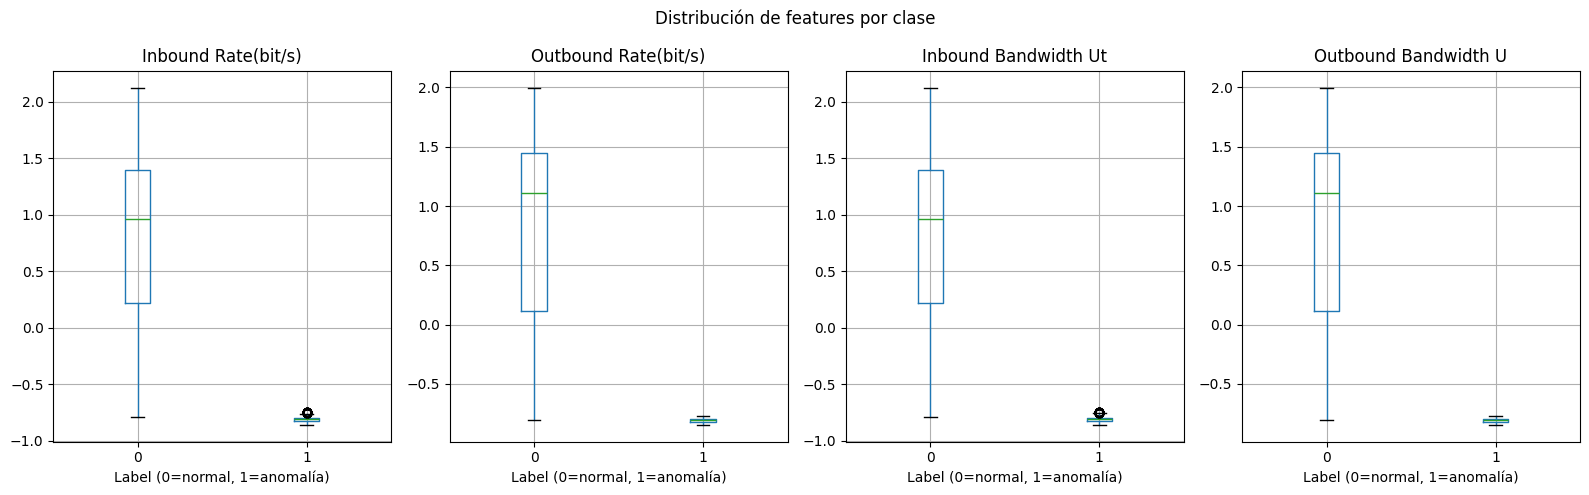

In [17]:
fig, axes = plt.subplots(1, 4, figsize=(16, 5))
for ax, col in zip(axes, df.columns):
    df.boxplot(column=col, by='Label', ax=ax)
    ax.set_title(col[:20])
    ax.set_xlabel('Label (0=normal, 1=anomalía)')
plt.suptitle('Distribución de features por clase')
plt.tight_layout()
plt.show()

# Separacion de datos

In [18]:
X = df.drop('Label', axis=1)
y = df['Label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Escalar datos
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Definir modelo
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')  # Clasificación binaria
])

# Compilar
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Entrenar
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stop],
    verbose=1
)

# Evaluar
y_pred = (model.predict(X_test) > 0.5).astype(int)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.94      0.97       247
           1       0.95      1.00      0.97       250

    accuracy                           0.97       497
   macro avg       0.97      0.97      0.97       497
weighted avg       0.97      0.97      0.97       497

[[233  14]
 [  0 250]]


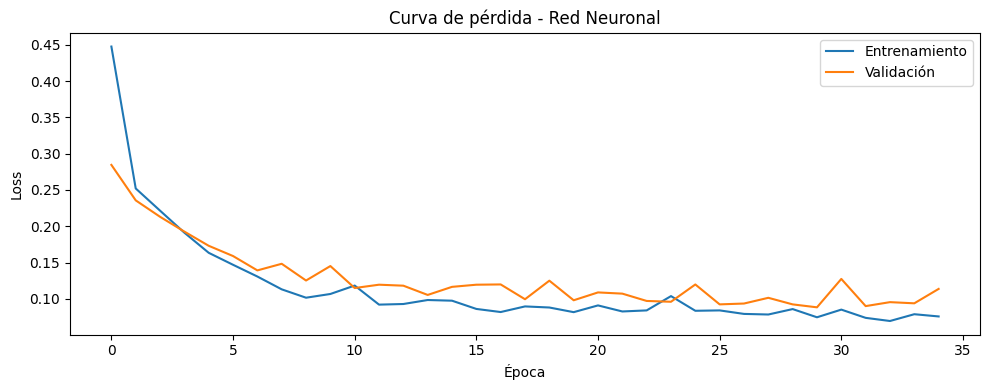

In [19]:
# Curva de pérdida durante el entrenamiento
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'], label='Entrenamiento')
plt.plot(history.history['val_loss'], label='Validación')
plt.title('Curva de pérdida - Red Neuronal')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()